In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.to_csv("titanic.csv", index=False)

In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [5]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print("Dataset Shape:")
print(df.shape)


Dataset Shape:
(891, 15)


In [ ]:
missing = df.isnull().mean() * 100

missing = missing[missing > 0]

print("Missing Value Percentage:")
print(missing)

age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


In [13]:
for column in missing.index:
    print(f"{column}: {missing[column]:.2f}% missing")

age: 19.87% missing
embarked: 0.22% missing
deck: 77.22% missing
embark_town: 0.22% missing


In [14]:
# Drop rows for columns with less than 5% missing values
df = df.dropna(subset=["embarked", "embark_town"])

# Impute age because its missing percentage is between 5% and 30%
df["age"] = df["age"].fillna(df["age"].median())

# Drop deck because its missing percentage is very high
df = df.drop(columns=["deck"])

In [15]:
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nShape after cleaning:")
print(df.shape)


Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Shape after cleaning:
(889, 14)


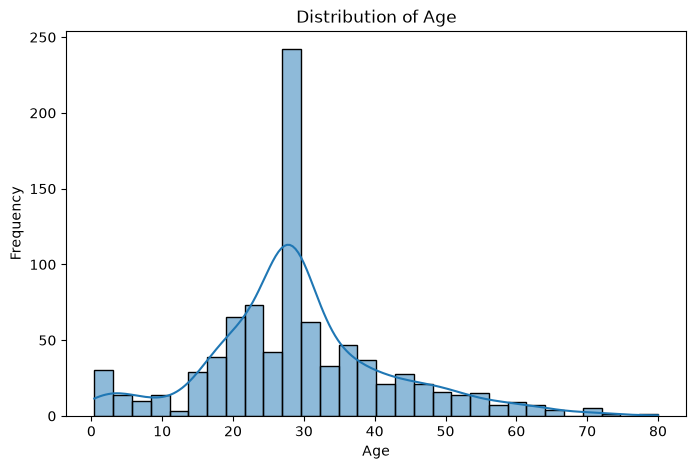

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], bins=30, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

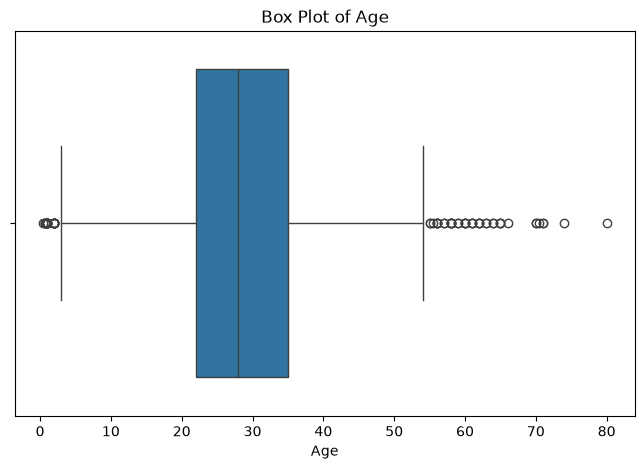

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["age"])

plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()

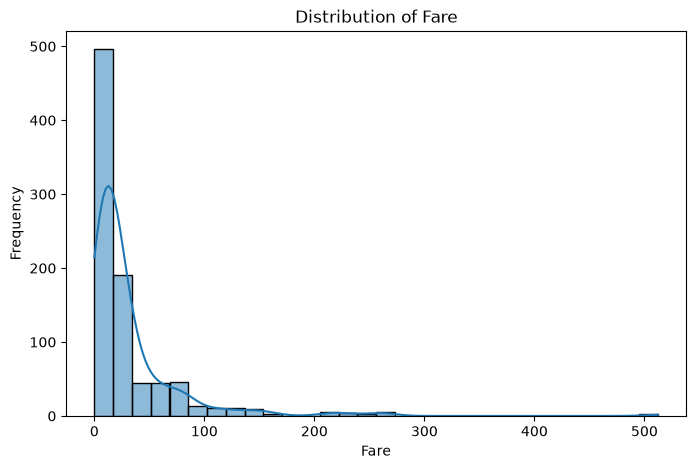

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(df["fare"], bins=30, kde=True)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

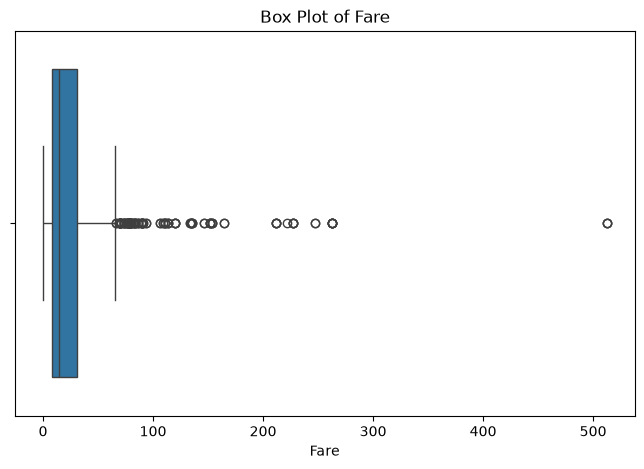

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["fare"])

plt.title("Box Plot of Fare")
plt.xlabel("Fare")
plt.show()

In [20]:
def count_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)


age_result = count_outliers("age")
fare_result = count_outliers("fare")

print("Age:")
print(age_result)

print("\nFare:")
print(fare_result)

Age:
(np.float64(22.0), np.float64(35.0), np.float64(13.0), np.float64(2.5), np.float64(54.5), 65)

Fare:
(np.float64(7.8958), np.float64(31.0), np.float64(23.1042), np.float64(-26.7605), np.float64(65.6563), 114)


In [23]:
def get_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    return Q1, Q3, IQR, lower_bound, upper_bound, outliers


# Age
age_Q1, age_Q3, age_IQR, age_lower, age_upper, age_outliers = get_outliers("age")

# Fare
fare_Q1, fare_Q3, fare_IQR, fare_lower, fare_upper, fare_outliers = get_outliers("fare")


print("AGE")
print(f"Q1: {age_Q1:.2f}")
print(f"Q3: {age_Q3:.2f}")
print(f"IQR: {age_IQR:.2f}")
print(f"Lower Bound: {age_lower:.2f}")
print(f"Upper Bound: {age_upper:.2f}")
print(f"Number of Outliers: {len(age_outliers)}")
print("\nAge Outlier Values:")
print(age_outliers["age"].sort_values().to_list())


print("\n" + "="*50 + "\n")


print("FARE")
print(f"Q1: {fare_Q1:.2f}")
print(f"Q3: {fare_Q3:.2f}")
print(f"IQR: {fare_IQR:.2f}")
print(f"Lower Bound: {fare_lower:.2f}")
print(f"Upper Bound: {fare_upper:.2f}")
print(f"Number of Outliers: {len(fare_outliers)}")
print("\nFare Outlier Values:")
print(fare_outliers["fare"].sort_values().to_list())

AGE
Q1: 22.00
Q3: 35.00
IQR: 13.00
Lower Bound: 2.50
Upper Bound: 54.50
Number of Outliers: 65

Age Outlier Values:
[0.42, 0.67, 0.75, 0.75, 0.83, 0.83, 0.92, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 55.0, 55.0, 55.5, 56.0, 56.0, 56.0, 56.0, 57.0, 57.0, 58.0, 58.0, 58.0, 58.0, 58.0, 59.0, 59.0, 60.0, 60.0, 60.0, 60.0, 61.0, 61.0, 61.0, 62.0, 62.0, 62.0, 63.0, 63.0, 64.0, 64.0, 65.0, 65.0, 65.0, 66.0, 70.0, 70.0, 70.5, 71.0, 71.0, 74.0, 80.0]


FARE
Q1: 7.90
Q3: 31.00
IQR: 23.10
Lower Bound: -26.76
Upper Bound: 65.66
Number of Outliers: 114

Fare Outlier Values:
[66.6, 66.6, 69.3, 69.3, 69.55, 69.55, 69.55, 69.55, 69.55, 69.55, 69.55, 71.0, 71.0, 71.2833, 73.5, 73.5, 73.5, 73.5, 73.5, 75.25, 76.2917, 76.7292, 76.7292, 76.7292, 77.2875, 77.2875, 77.9583, 77.9583, 77.9583, 78.2667, 78.2667, 78.85, 78.85, 79.2, 79.2, 79.2, 79.2, 79.65, 79.65, 79.65, 81.8583, 82.1708, 82.1708, 83.1583, 83.1583, 83.1583, 83.475, 83.475, 86.5, 86.5, 86.5, 89.1042, 8

In [24]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print(f"Mean Fare   : {fare_mean:.2f}")
print(f"Median Fare : {fare_median:.2f}")
print(f"Mode Fare   : {fare_mode:.2f}")

Mean Fare   : 32.10
Median Fare : 14.45
Mode Fare   : 8.05


In [25]:
fare_skewness = df["fare"].skew()

print(f"Fare Skewness: {fare_skewness:.2f}")

if fare_mean > fare_median > fare_mode:
    print("Fare distribution is right-skewed.")
elif fare_mean < fare_median < fare_mode:
    print("Fare distribution is left-skewed.")
else:
    print("Fare distribution is approximately symmetric.")

Fare Skewness: 4.80
Fare distribution is right-skewed.


In [26]:
male_survival = df[df["sex"] == "male"]["survived"].mean() * 100
female_survival = df[df["sex"] == "female"]["survived"].mean() * 100

print(f"Male survival rate   : {male_survival:.2f}%")
print(f"Female survival rate : {female_survival:.2f}%")

Male survival rate   : 18.89%
Female survival rate : 74.04%


In [27]:
first_class = df[df["pclass"] == 1]["survived"].mean() * 100
second_class = df[df["pclass"] == 2]["survived"].mean() * 100
third_class = df[df["pclass"] == 3]["survived"].mean() * 100

print(f"1st Class survival rate : {first_class:.2f}%")
print(f"2nd Class survival rate : {second_class:.2f}%")
print(f"3rd Class survival rate : {third_class:.2f}%")

1st Class survival rate : 62.62%
2nd Class survival rate : 47.28%
3rd Class survival rate : 24.24%


In [28]:
female_first = df[
    (df["sex"] == "female") & (df["pclass"] == 1)
]["survived"].mean() * 100

female_second = df[
    (df["sex"] == "female") & (df["pclass"] == 2)
]["survived"].mean() * 100

female_third = df[
    (df["sex"] == "female") & (df["pclass"] == 3)
]["survived"].mean() * 100


male_first = df[
    (df["sex"] == "male") & (df["pclass"] == 1)
]["survived"].mean() * 100

male_second = df[
    (df["sex"] == "male") & (df["pclass"] == 2)
]["survived"].mean() * 100

male_third = df[
    (df["sex"] == "male") & (df["pclass"] == 3)
]["survived"].mean() * 100


print("Female:")
print(f"1st Class : {female_first:.2f}%")
print(f"2nd Class : {female_second:.2f}%")
print(f"3rd Class : {female_third:.2f}%")

print("\nMale:")
print(f"1st Class : {male_first:.2f}%")
print(f"2nd Class : {male_second:.2f}%")
print(f"3rd Class : {male_third:.2f}%")

Female:
1st Class : 96.74%
2nd Class : 92.11%
3rd Class : 50.00%

Male:
1st Class : 36.89%
2nd Class : 15.74%
3rd Class : 13.54%


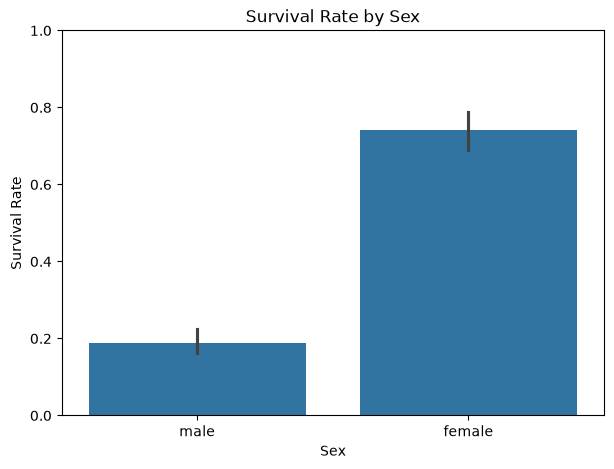

In [34]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

### Interpretation

The chart shows a clear difference in survival rates between male and female passengers.
The survival rate for females was [74.04%], while the survival rate for males was [18.89%].
This indicates that sex was associated with survival outcomes in the Titanic dataset.

In [29]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[correlation_columns].corr()

print(corr_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


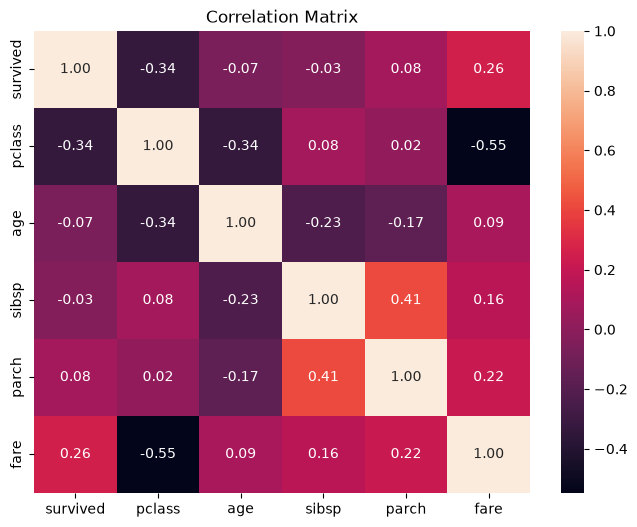

In [30]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [31]:
corr_pairs = []

for i in range(len(correlation_columns)):
    for j in range(i + 1, len(correlation_columns)):
        
        col1 = correlation_columns[i]
        col2 = correlation_columns[j]
        
        correlation = corr_matrix.loc[col1, col2]
        
        corr_pairs.append(
            (col1, col2, correlation, abs(correlation))
        )

corr_pairs = sorted(
    corr_pairs,
    key=lambda x: x[3],
    reverse=True
)

print("Top 2 strongest correlations:\n")

for pair in corr_pairs[:2]:
    print(f"{pair[0]} ↔ {pair[1]} : {pair[2]:.3f}")

Top 2 strongest correlations:

pclass ↔ fare : -0.548
sibsp ↔ parch : 0.415


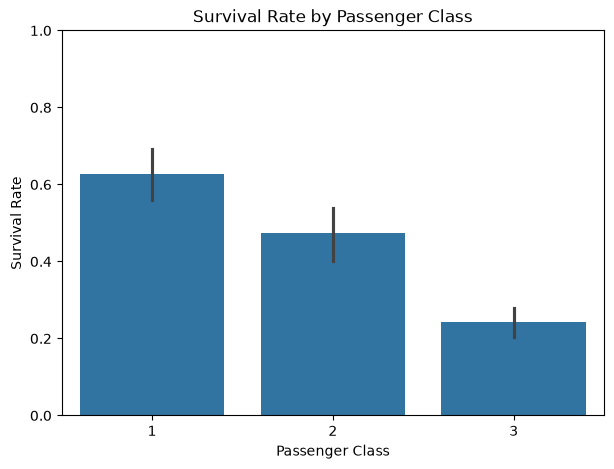

In [35]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

### Interpretation

The chart compares survival rates across the three passenger classes.
Passengers in Class [1] had the highest survival rate, while Class [3] had the lowest.
This shows that passenger class was associated with differences in survival outcomes.

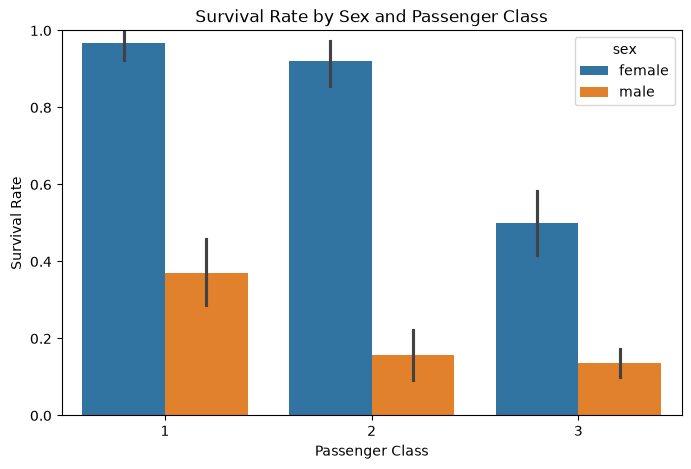

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

### Interpretation

The chart shows survival rates across passenger classes separately for males and females.
Survival rates vary not only by sex but also by passenger class.
The combination of these variables provides a more detailed view of the survival pattern than either variable alone.

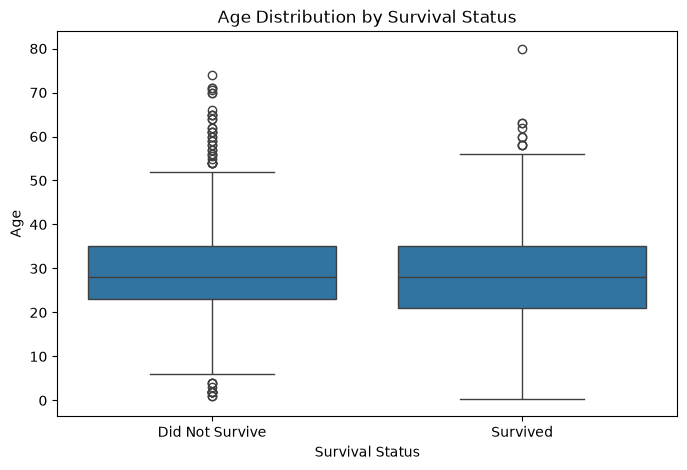

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Age")

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.show()

### Interpretation

The box plot compares the age distributions of passengers who survived and those who did not survive.
The median and spread of age can be compared between the two survival groups.
This helps identify whether age shows a noticeable relationship with survival in the dataset.

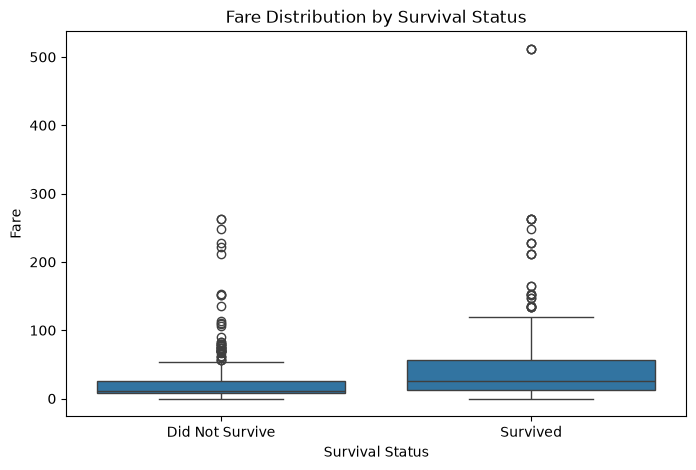

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Fare")

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.show()

### Interpretation

The box plot compares fare distributions between passengers who survived and those who did not.
The median and spread of fares differ between the two groups.
This provides another indication of the relationship between passenger fare and survival.

### Scaling


In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()

df_standardized = df.copy()

df_standardized[["age", "fare"]] = scaler.fit_transform(
    df[["age", "fare"]]
)

In [41]:
print("Before Standardization:")
print(df[["age", "fare"]].agg(["mean", "std"]))

print("\nAfter Standardization:")
print(df_standardized[["age", "fare"]].agg(["mean", "std"]))

Before Standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After Standardization:
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


### Standardization Interpretation

Age and fare were standardized using the z-score transformation:
z = (x - mean) / standard deviation.

Before standardization, age and fare had different means and standard deviations.
After standardization, both variables have approximately mean 0 and standard deviation 1.
This confirms that the standardization transformation was applied correctly.

In [42]:
df.to_csv("titanic.csv", index=False)

print("Final cleaned dataset saved successfully.")
print("Shape:", df.shape)

Final cleaned dataset saved successfully.
Shape: (889, 14)
